Задание
Создайте систему компьютерного зрения, которая будет определять тип геометрической :фигуры. Используя подготовленную базу и шаблон ноутбука проведите серию экспериментов по перебору гиперпараметров нейронной сети, распознающей три категории изображений (треугольник, круг, квадрат).

1. Поменяйте количество нейронов в сети, используя следующие значения:

- один слой 10 нейронов
- один слой 100 нейронов
- один слой 5000 нейронов.

2. Поменяйте активационную функцию в скрытых слоях с `relu` на `linear`.
3. Поменяйте размеры batch_size:
- 10
- 100
- 1000

4. Выведите на экран получившиеся точности.

Всего должно получиться 18 комбинаций указанных параметров.

### Создайте сравнительную таблицу по результатам проведенных тестов.

In [1]:
from tensorflow import keras
from keras.layers import Dense, Flatten
from keras.models import Sequential
from keras.optimizers import Adam
from keras import utils
from keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import os
%matplotlib inline

In [2]:
# Функция для построения графиков точности и функции потерь
def plot_training_graphs(history, title=''):
    title_suffix = f' — {title}' if title else ''

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    if 'accuracy' in history.history:
        plt.plot(history.history['accuracy'], label='точность обучения')
    if 'val_accuracy' in history.history:
        plt.plot(history.history['val_accuracy'], label='точность проверки')
    plt.title('График точности' + title_suffix)
    plt.xlabel('Эпоха')
    plt.ylabel('Точность')
    plt.legend()

    plt.subplot(1, 2, 2)
    if 'loss' in history.history:
        plt.plot(history.history['loss'], label='потери обучения')
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='потери проверки')
    plt.title('График функции потерь' + title_suffix)
    plt.xlabel('Эпоха')
    plt.ylabel('Потери')
    plt.legend()

    plt.tight_layout()
    plt.show()


In [3]:
import gdown
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l3/hw_light.zip', None, quiet=True)

'hw_light.zip'

In [4]:
!unzip -q hw_light.zip

In [5]:
# Путь к директории с базой
base_dir = '/content/hw_light'
# Создание пустого списка для загрузки изображений обучающей выборки
x_train = []
# Создание списка для меток классов
y_train = []
# Задание высоты и ширины загружаемых изображений
img_height = 20
img_width = 20
# Перебор папок в директории базы
for patch in os.listdir(base_dir):
    # Перебор файлов в папках
    for img in os.listdir(base_dir + '/' + patch):
        # Добавление в список изображений текущей картинки
        x_train.append(image.img_to_array(image.load_img(base_dir + '/' + patch + '/' + img,
                                                    target_size=(img_height, img_width),
                                                    color_mode='grayscale')))
        # Добавление в массив меток, соответствующих классам
        if patch == '0':
            y_train.append(0)
        elif patch == '3':
            y_train.append(1)
        else:
            y_train.append(2)

# Преобразование в numpy-массив загруженных изображений и меток классов
x_train = np.array(x_train)
y_train = np.array(y_train)
# Вывод размерностей
print('Размер массива x_train', x_train.shape)
print('Размер массива y_train', y_train.shape)

Размер массива x_train (302, 20, 20, 1)
Размер массива y_train (302,)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4813 - loss: 4.4985 - val_accuracy: 0.0000e+00 - val_loss: 16.6067
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5270 - loss: 4.7173 - val_accuracy: 0.0000e+00 - val_loss: 16.5499
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5187 - loss: 4.8875 - val_accuracy: 0.0000e+00 - val_loss: 16.5499
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5519 - loss: 4.0933 - val_accuracy: 0.0000e+00 - val_loss: 16.8112
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5851 - loss: 3.4621 - val_accuracy: 0.0000e+00 - val_loss: 16.8112
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5560 - loss: 3.4571 - val_accuracy: 0.0000e+00 - val_loss: 16.8112
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5519 - loss: 3.4571 - val_accuracy: 0.0000e+00 - val_loss: 16.8112
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5519 - loss: 3.4571 - val_acc

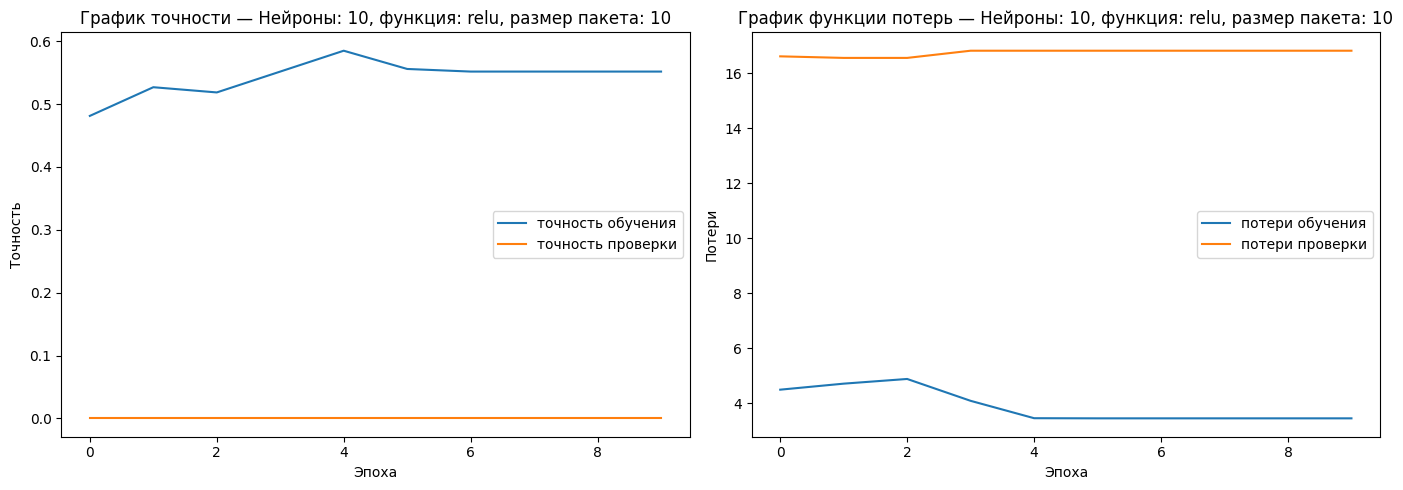

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4404 - loss: 6.1545 


In [6]:
model = Sequential() # Создание модели

# Добавление слоев с 10 нейронами, функция активации relu
model.add(Flatten(input_shape=(20, 20, 1)))
model.add(Dense(10, input_dim = 400, activation='relu'))
model.add(Dense(3))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Задание batch_size=100
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=10,
    validation_split=0.2,
    verbose=1
)

plot_training_graphs(history, "Нейроны: 10, функция: relu, размер пакета: 10")

# Измерение точности
loss, accuracy = model.evaluate(x_train, y_train)

# Список комбинаций параметров
results = []
results.append([10, "relu", 10, accuracy])

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 217ms/step - accuracy: 0.3859 - loss: 3.1507 - val_accuracy: 0.1148 - val_loss: 1.0986
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.3859 - loss: 3.1507 - val_accuracy: 0.1148 - val_loss: 1.0986
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.3859 - loss: 3.1507 - val_accuracy: 0.1148 - val_loss: 1.0986
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.3859 - loss: 3.1507 - val_accuracy: 0.1148 - val_loss: 1.0986
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.3859 - loss: 3.1507 - val_accuracy: 0.1148 - val_loss: 1.0986
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.3859 - loss: 3.1507 - val_accuracy: 0.1148 - val_loss: 1.0986
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.3859 - loss: 3.1507 - val_accuracy: 0.1148 - val_loss: 1.0986
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.3859 - loss: 3.1507 - val_accuracy: 0.1148 - val_loss: 1.0986

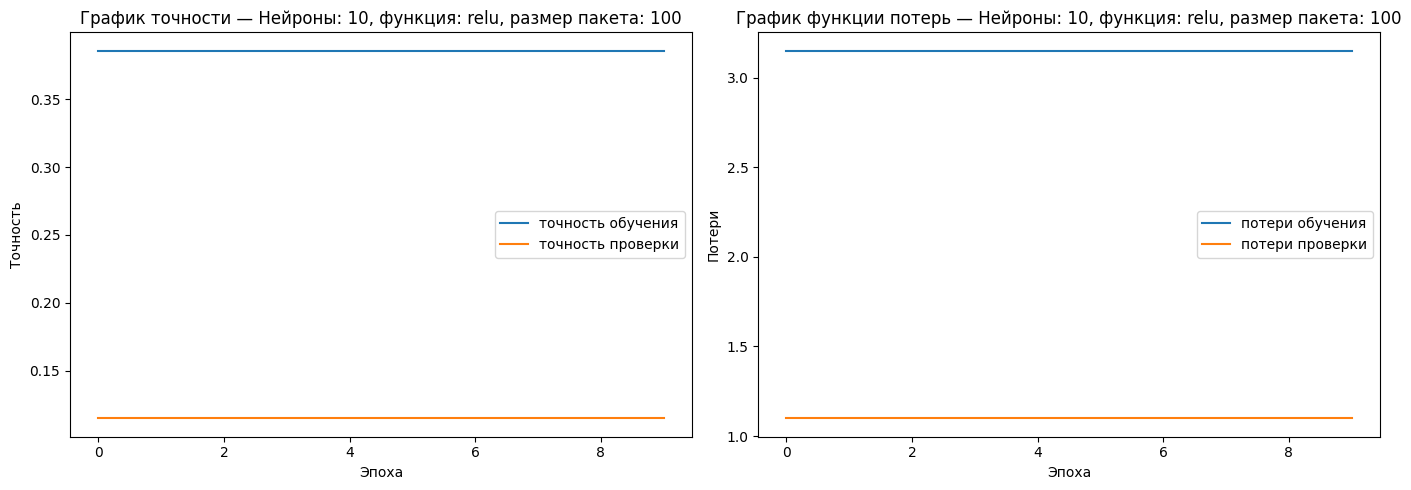

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3311 - loss: 2.7362     


In [7]:
model = Sequential() # Создание модели

# Добавление слоев с 10 нейронами, функция активации relu
model.add(Flatten(input_shape=(20, 20, 1)))
model.add(Dense(10, input_dim = 400, activation='relu'))
model.add(Dense(3))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Задание batch_size=10
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=100,
    validation_split=0.2,
    verbose=1
)

plot_training_graphs(history, "Нейроны: 10, функция: relu, размер пакета: 100")

# Измерение точности
loss, accuracy = model.evaluate(x_train, y_train)

# Список комбинаций параметров
results.append([10, "relu", 100, accuracy])

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.4274 - loss: 3.9238 - val_accuracy: 0.0000e+00 - val_loss: 15.7335
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.4274 - loss: 3.9267 - val_accuracy: 0.0000e+00 - val_loss: 15.9911
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.4191 - loss: 3.9349 - val_accuracy: 0.0000e+00 - val_loss: 16.7999
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.4357 - loss: 3.5285 - val_accuracy: 0.0000e+00 - val_loss: 16.8112
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.4523 - loss: 3.5275 - val_accuracy: 0.0000e+00 - val_loss: 16.8112
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.4813 - loss: 3.4623 - val_accuracy: 0.0000e+00 - val_loss: 16.8112
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.4938 - loss: 3.3926 - val_accuracy: 0.0000e+00 - val_loss: 16.8112
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.5270 - loss: 3.3926 - val_a

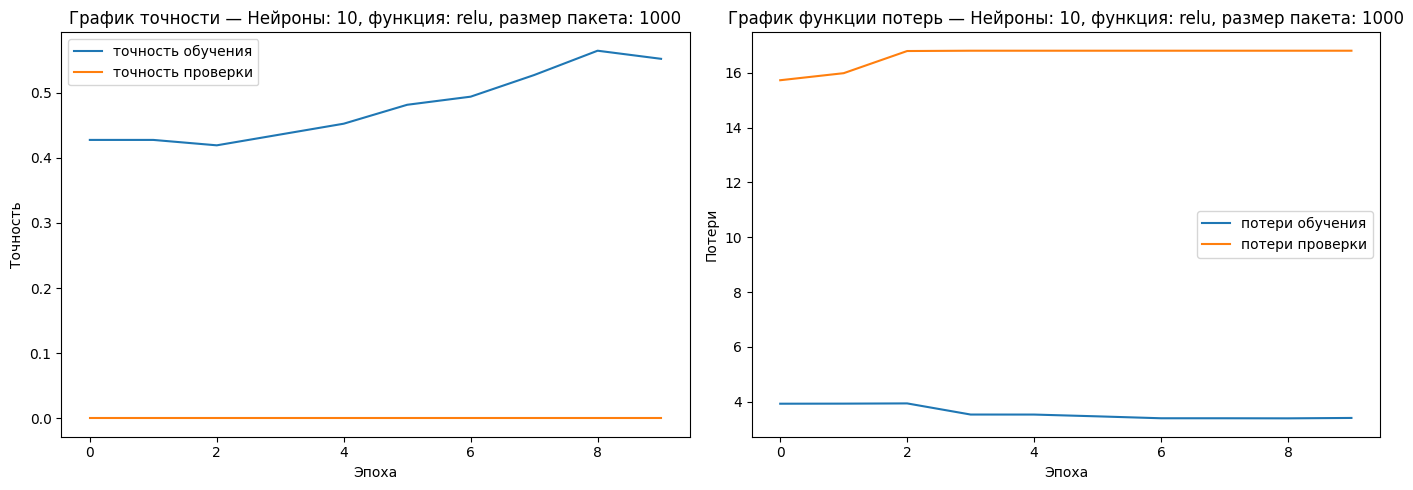

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4437 - loss: 6.1190 


In [8]:
model = Sequential() # Создание модели

# Добавление слоев с 10 нейронами, функция активации relu
model.add(Flatten(input_shape=(20, 20, 1)))
model.add(Dense(10, input_dim = 400, activation='relu'))
model.add(Dense(3))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Задание batch_size=1000
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=1000,
    validation_split=0.2,
    verbose=1
)

plot_training_graphs(history, "Нейроны: 10, функция: relu, размер пакета: 1000")

# Измерение точности
loss, accuracy = model.evaluate(x_train, y_train)

# Список комбинаций параметров
results.append([10, "relu", 1000, accuracy])

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.2573 - loss: 9.6578 - val_accuracy: 0.0000e+00 - val_loss: 1.4518
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4149 - loss: 7.3675 - val_accuracy: 0.0000e+00 - val_loss: 2.2104
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4149 - loss: 7.3560 - val_accuracy: 0.0000e+00 - val_loss: 2.2104
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4149 - loss: 7.3560 - val_accuracy: 0.0000e+00 - val_loss: 2.2104
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4149 - loss: 7.3560 - val_accuracy: 0.0000e+00 - val_loss: 2.2104
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4149 - loss: 7.3560 - val_accuracy: 0.0000e+00 - val_loss: 2.2104
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4149 - loss: 7.3560 - val_accuracy: 0.0000e+00 - val_loss: 2.2104
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4149 - loss: 7.3560 - val

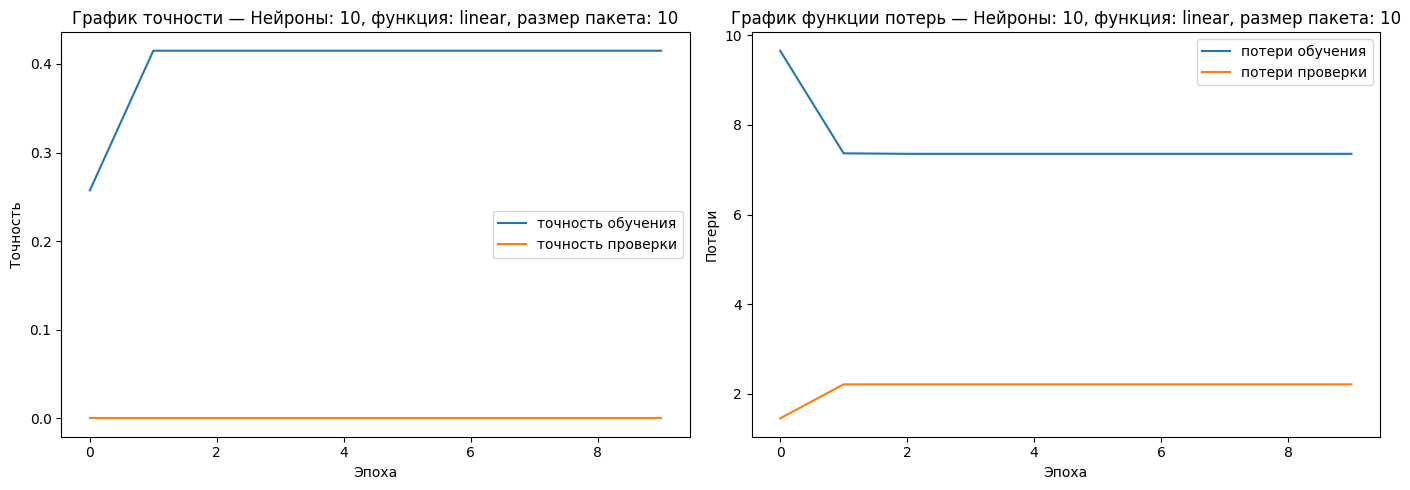

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3311 - loss: 6.3166 


In [9]:
model = Sequential() # Создание модели

# Добавление слоев с 10 нейронами, функция активации linear
model.add(Flatten(input_shape=(20, 20, 1)))
model.add(Dense(10, input_dim = 400, activation='linear'))
model.add(Dense(3))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Задание batch_size=10
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=10,
    validation_split=0.2,
    verbose=1
)

plot_training_graphs(history, "Нейроны: 10, функция: linear, размер пакета: 10")

# Измерение точности
loss, accuracy = model.evaluate(x_train, y_train)

# Список комбинаций параметров
results.append([10, "linear", 10, accuracy])

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - accuracy: 0.3485 - loss: 6.0210 - val_accuracy: 0.0000e+00 - val_loss: 16.4059
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3361 - loss: 6.6004 - val_accuracy: 0.0000e+00 - val_loss: 16.6522
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3278 - loss: 6.9792 - val_accuracy: 0.0000e+00 - val_loss: 16.5953
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.3402 - loss: 7.2235 - val_accuracy: 0.0000e+00 - val_loss: 16.5499
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3320 - loss: 7.3038 - val_accuracy: 0.0000e+00 - val_loss: 16.0120
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3320 - loss: 7.3626 - val_accuracy: 0.0000e+00 - val_loss: 15.5196
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3237 - loss: 7.4196 - val_accuracy: 0.0000e+00 - val_loss: 15.4874
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3237 - loss: 7.6681 - val_

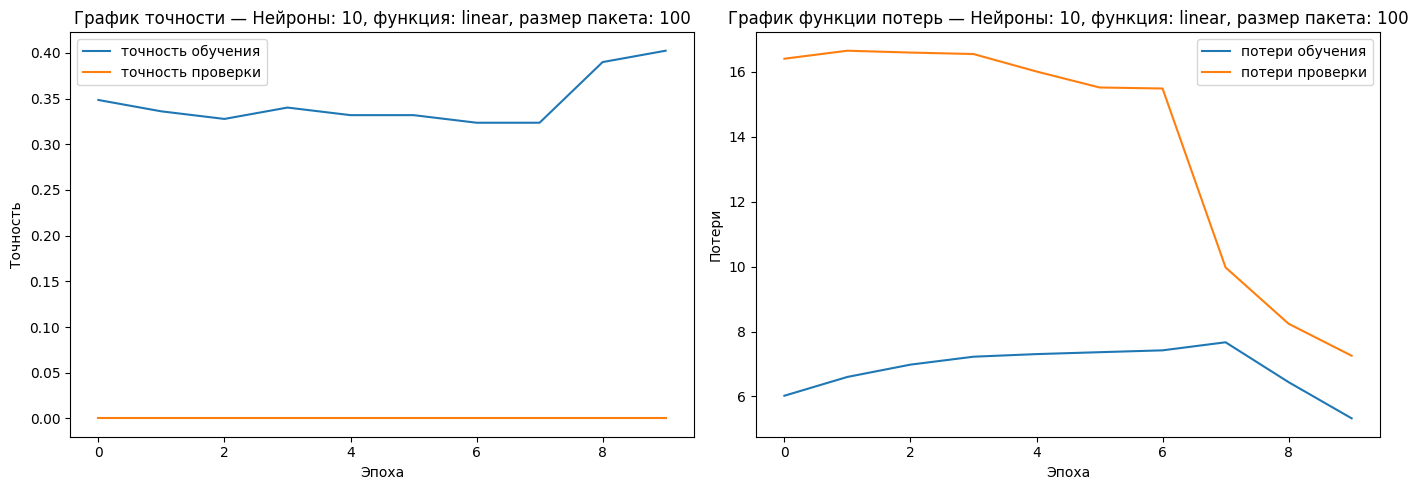

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3311 - loss: 5.4144     


In [10]:
model = Sequential() # Создание модели

# Добавление слоев с 10 нейронами, функция активации linear
model.add(Flatten(input_shape=(20, 20, 1)))
model.add(Dense(10, input_dim = 400, activation='linear'))
model.add(Dense(3))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Задание batch_size=100
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=100,
    validation_split=0.2,
    verbose=1
)

plot_training_graphs(history, "Нейроны: 10, функция: linear, размер пакета: 100")

# Измерение точности
loss, accuracy = model.evaluate(x_train, y_train)

# Список комбинаций параметров
results.append([10, "linear", 100, accuracy])

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.2324 - loss: 7.6667 - val_accuracy: 0.9672 - val_loss: 0.6931
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 357ms/step - accuracy: 0.2324 - loss: 7.6667 - val_accuracy: 0.9672 - val_loss: 0.6931
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.2324 - loss: 7.6667 - val_accuracy: 0.9672 - val_loss: 0.6931
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.2324 - loss: 7.6667 - val_accuracy: 0.9672 - val_loss: 0.6931
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.2324 - loss: 7.6667 - val_accuracy: 0.9672 - val_loss: 0.6931
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.2324 - loss: 7.6667 - val_accuracy: 0.9672 - val_loss: 0.6931
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.2324 - loss: 7.6667 - val_accuracy: 0.9672 - val_loss: 0.6931
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.2324 - loss: 7.6667 - val_accuracy: 0.9672 - val_loss: 0.

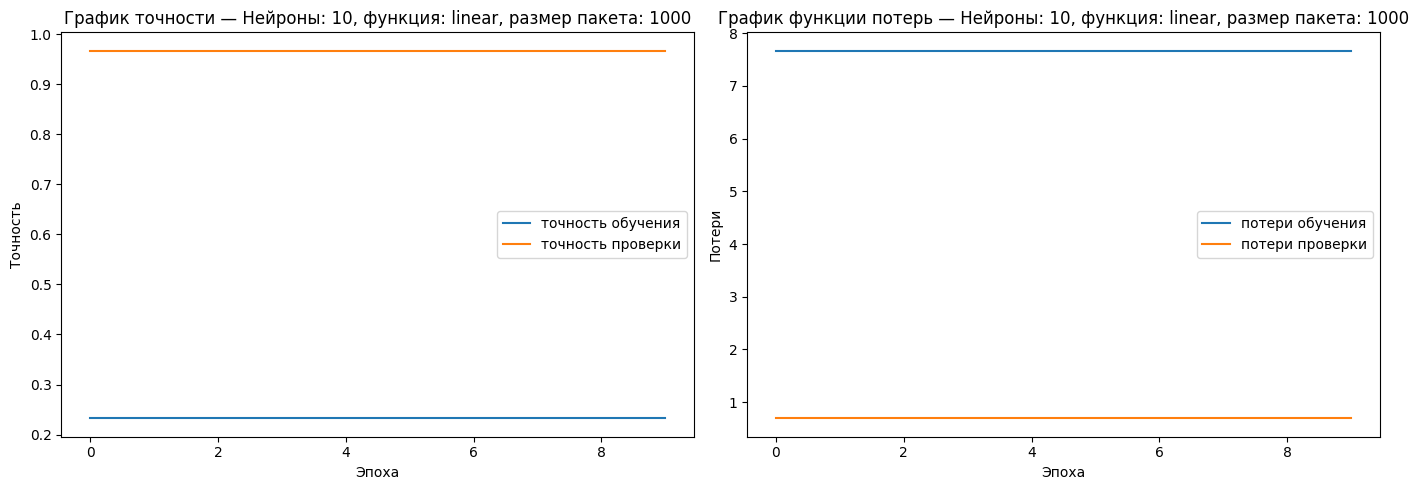

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3808 - loss: 6.2582 


In [11]:
model = Sequential() # Создание модели

# Добавление слоев с 10 нейронами, функция активации linear
model.add(Flatten(input_shape=(20, 20, 1)))
model.add(Dense(10, input_dim = 400, activation='linear'))
model.add(Dense(3))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Задание batch_size=1000
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=1000,
    validation_split=0.2,
    verbose=1
)

plot_training_graphs(history, "Нейроны: 10, функция: linear, размер пакета: 1000")

# Измерение точности
loss, accuracy = model.evaluate(x_train, y_train)

# Список комбинаций параметров
results.append([10, "linear", 1000, accuracy])

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4108 - loss: 8.6069 - val_accuracy: 0.0000e+00 - val_loss: 7.7735
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4108 - loss: 8.6069 - val_accuracy: 0.0000e+00 - val_loss: 7.7735
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4108 - loss: 8.6069 - val_accuracy: 0.0000e+00 - val_loss: 7.7735
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4108 - loss: 8.6069 - val_accuracy: 0.0000e+00 - val_loss: 7.7735
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4108 - loss: 8.6068 - val_accuracy: 0.0000e+00 - val_loss: 7.7735
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4108 - loss: 8.6069 - val_accuracy: 0.0000e+00 - val_loss: 7.7735
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4108 - loss: 8.6069 - val_accuracy: 0.0000e+00 - val_loss: 7.7735
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4108 - loss: 8.6069 - val

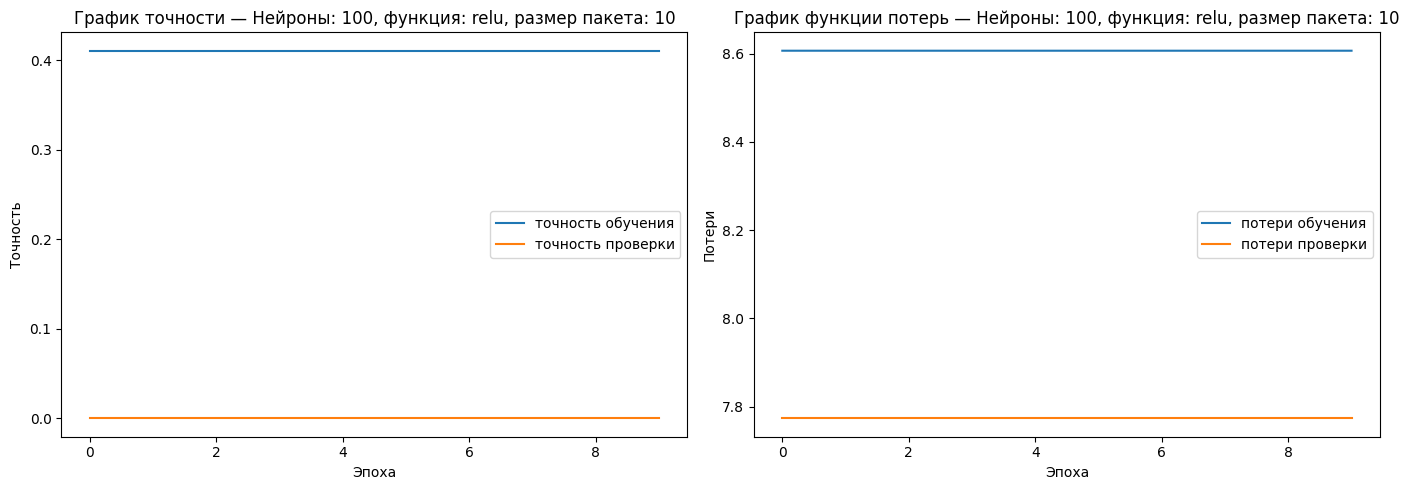

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3278 - loss: 8.4385 


In [12]:
model = Sequential() # Создание модели

# Добавление слоев с 100 нейронами, функция активации relu
model.add(Flatten(input_shape=(20, 20, 1)))
model.add(Dense(100, input_dim = 400, activation='relu'))
model.add(Dense(3))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Задание batch_size=10
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=10,
    validation_split=0.2,
    verbose=1
)

plot_training_graphs(history, "Нейроны: 100, функция: relu, размер пакета: 10")

# Измерение точности
loss, accuracy = model.evaluate(x_train, y_train)

# Список комбинаций параметров
results.append([100, "relu", 10, accuracy])

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.4357 - loss: 4.8762 - val_accuracy: 0.0000e+00 - val_loss: 16.1181
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4191 - loss: 9.3860 - val_accuracy: 0.0000e+00 - val_loss: 16.1181
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4149 - loss: 9.4301 - val_accuracy: 0.0000e+00 - val_loss: 16.1181
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4149 - loss: 9.4301 - val_accuracy: 0.0000e+00 - val_loss: 16.1181
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4149 - loss: 9.4301 - val_accuracy: 0.0000e+00 - val_loss: 16.1181
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4149 - loss: 9.4301 - val_accuracy: 0.0000e+00 - val_loss: 16.1181
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4149 - loss: 9.4301 - val_accuracy: 0.0000e+00 - val_loss: 16.1181
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4149 - loss: 9.4301 - val_

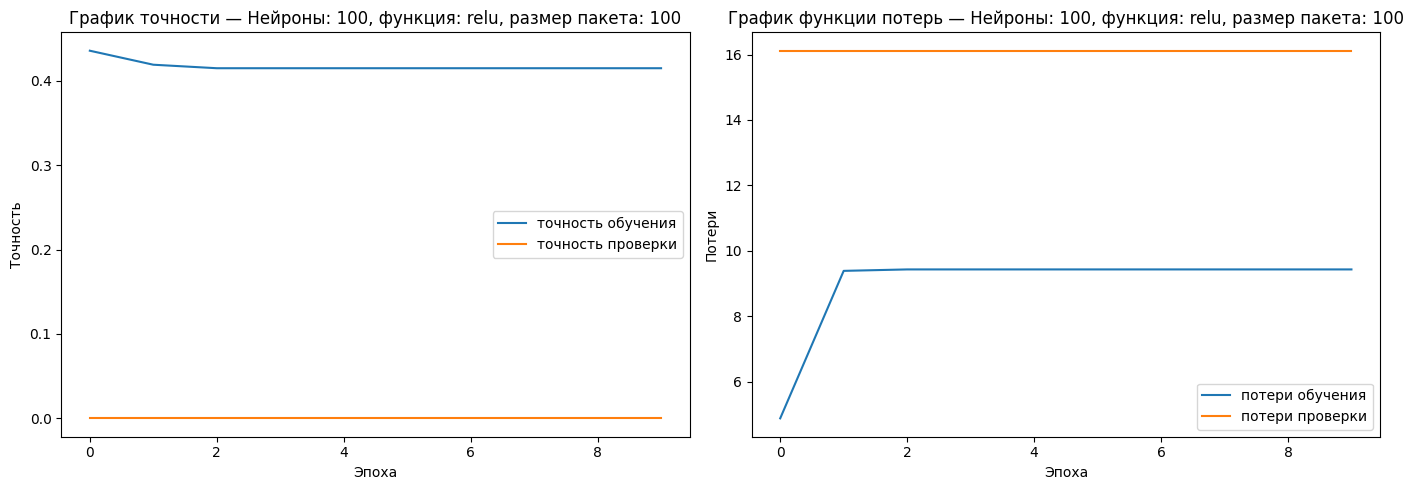

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3311 - loss: 10.7810    


In [13]:
model = Sequential() # Создание модели

# Добавление слоев с 100 нейронами, функция активации relu
model.add(Flatten(input_shape=(20, 20, 1)))
model.add(Dense(100, input_dim = 400, activation='relu'))
model.add(Dense(3))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Задание batch_size=100
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=100,
    validation_split=0.2,
    verbose=1
)

plot_training_graphs(history, "Нейроны: 100, функция: relu, размер пакета: 100")

# Измерение точности
loss, accuracy = model.evaluate(x_train, y_train)

# Список комбинаций параметров
results.append([100, "relu", 100, accuracy])

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.4149 - loss: 8.2971 - val_accuracy: 0.0000e+00 - val_loss: 13.6593
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.4149 - loss: 8.3549 - val_accuracy: 0.0000e+00 - val_loss: 13.9135
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.4149 - loss: 8.5327 - val_accuracy: 0.0000e+00 - val_loss: 13.9135
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.4149 - loss: 8.5282 - val_accuracy: 0.0000e+00 - val_loss: 14.1232
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.4149 - loss: 8.5282 - val_accuracy: 0.0000e+00 - val_loss: 14.1597
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.4149 - loss: 8.6400 - val_accuracy: 0.0000e+00 - val_loss: 7.4982
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.4191 - loss: 5.5367 - val_accuracy: 0.0492 - val_loss: 2.8222
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 0.4232 - loss: 3.1292 - val_accuracy:

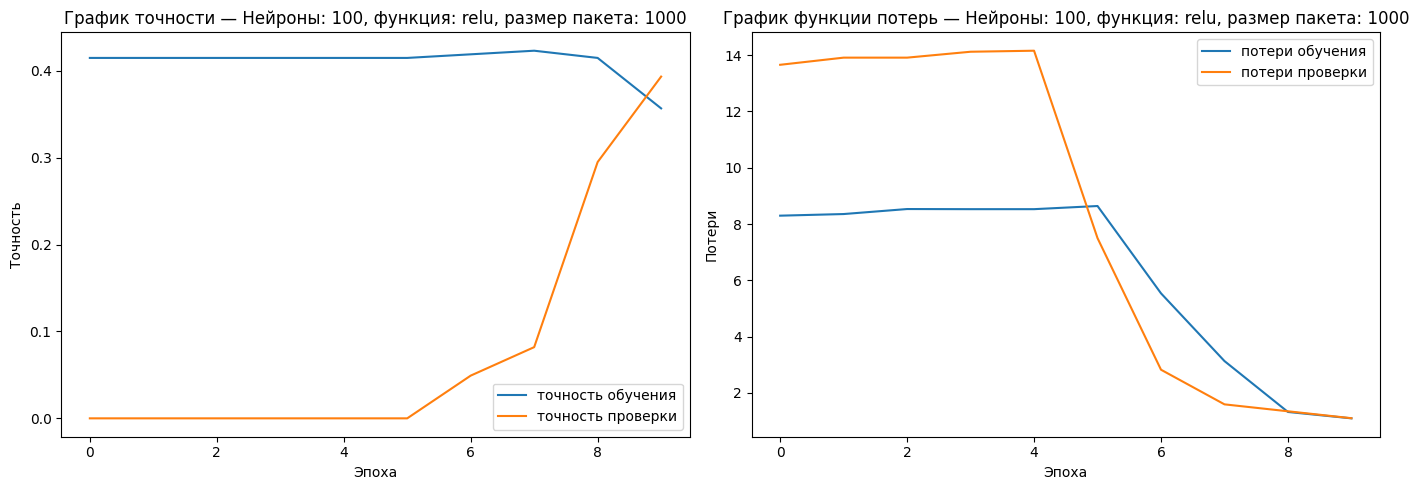

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3444 - loss: 1.0950 


In [14]:
model = Sequential() # Создание модели

# Добавление слоев с 100 нейронами, функция активации relu
model.add(Flatten(input_shape=(20, 20, 1)))
model.add(Dense(100, input_dim = 400, activation='relu'))
model.add(Dense(3))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Задание batch_size=1000
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=1000,
    validation_split=0.2,
    verbose=1
)

plot_training_graphs(history, "Нейроны: 100, функция: relu, размер пакета: 1000")

# Измерение точности
loss, accuracy = model.evaluate(x_train, y_train)

# Список комбинаций параметров
results.append([100, "relu", 1000, accuracy])

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.4315 - loss: 5.4468 - val_accuracy: 0.0000e+00 - val_loss: 13.4551
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4149 - loss: 6.9001 - val_accuracy: 0.0000e+00 - val_loss: 13.6900
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4066 - loss: 5.4052 - val_accuracy: 0.0000e+00 - val_loss: 3.5608
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4149 - loss: 5.1784 - val_accuracy: 0.0000e+00 - val_loss: 6.7168
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3693 - loss: 4.6974 - val_accuracy: 1.0000 - val_loss: 1.0986
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1701 - loss: 1.0986 - val_accuracy: 1.0000 - val_loss: 1.0986
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1701 - loss: 1.0986 - val_accuracy: 1.0000 - val_loss: 1.0986
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1701 - loss: 1.0986 - val_accuracy:

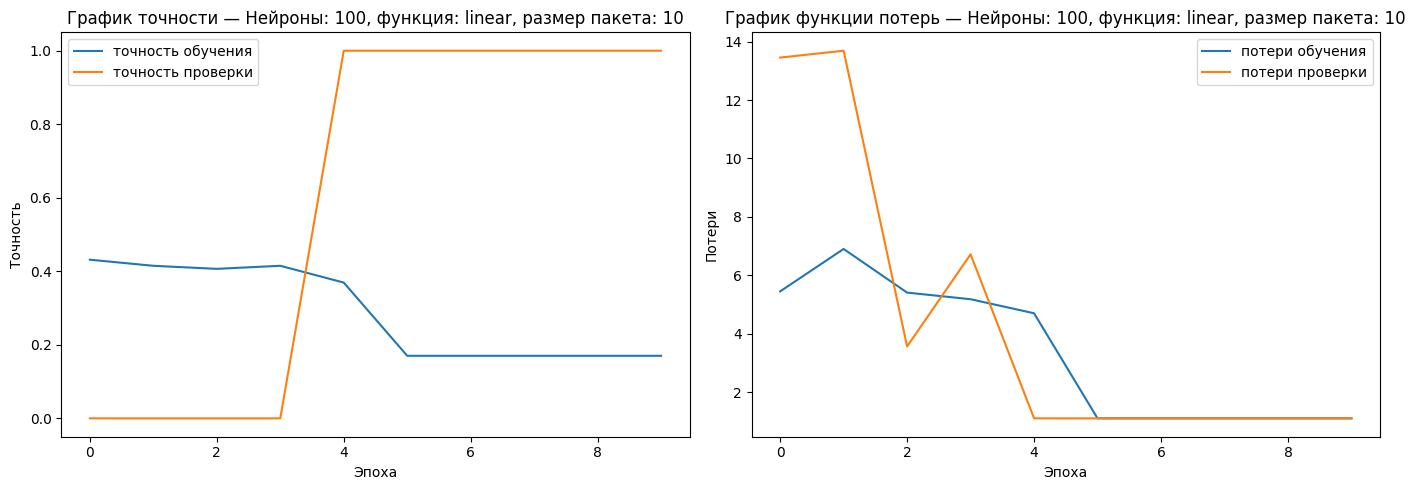

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3377 - loss: 1.0986     


In [15]:
model = Sequential() # Создание модели

# Добавление слоев с 100 нейронами, функция активации linear
model.add(Flatten(input_shape=(20, 20, 1)))
model.add(Dense(100, input_dim = 400, activation='linear'))
model.add(Dense(3))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Задание batch_size=10
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=10,
    validation_split=0.2,
    verbose=1
)

plot_training_graphs(history, "Нейроны: 100, функция: linear, размер пакета: 10")

# Измерение точности
loss, accuracy = model.evaluate(x_train, y_train)

# Список комбинаций параметров
results.append([100, "linear", 10, accuracy])

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.3361 - loss: 7.3346 - val_accuracy: 0.0000e+00 - val_loss: 14.6900
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3361 - loss: 7.3346 - val_accuracy: 0.0000e+00 - val_loss: 14.6900
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.3361 - loss: 7.3346 - val_accuracy: 0.0000e+00 - val_loss: 14.6900
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.3361 - loss: 7.3346 - val_accuracy: 0.0000e+00 - val_loss: 14.6900
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3361 - loss: 7.3346 - val_accuracy: 0.0000e+00 - val_loss: 14.6900
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3361 - loss: 7.3346 - val_accuracy: 0.0000e+00 - val_loss: 14.6900
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3361 - loss: 7.3346 - val_accuracy: 0.0000e+00 - val_loss: 14.6900
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.3361 - loss: 7.3346 - val_

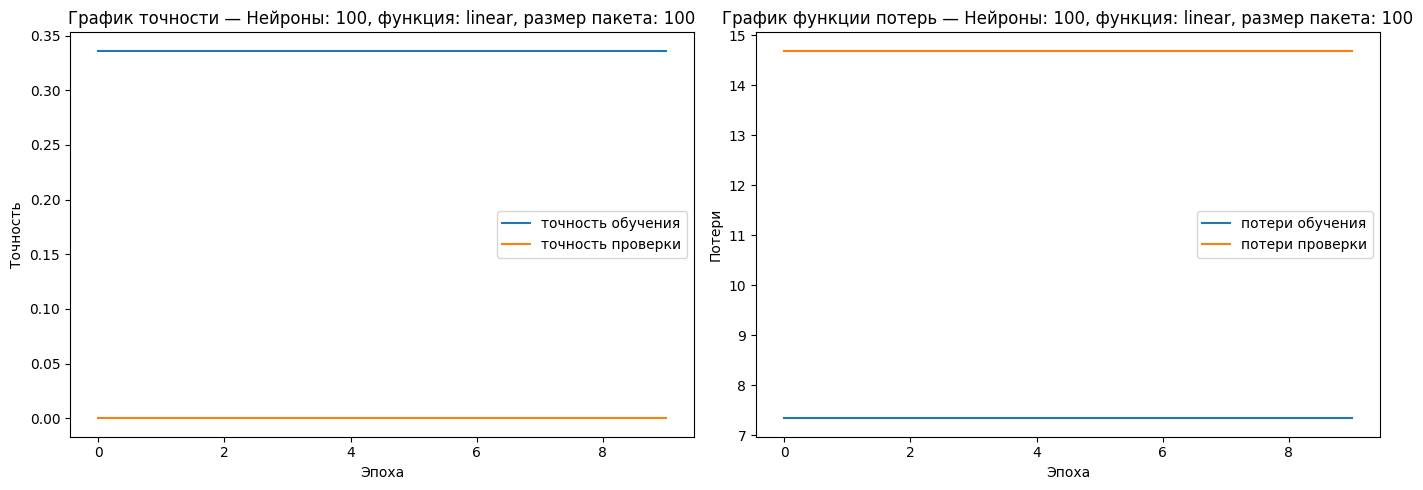

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2682 - loss: 8.8203 


In [16]:
model = Sequential() # Создание модели

# Добавление слоев с 100 нейронами, функция активации linear
model.add(Flatten(input_shape=(20, 20, 1)))
model.add(Dense(100, input_dim = 400, activation='linear'))
model.add(Dense(3))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Задание batch_size=100
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=100,
    validation_split=0.2,
    verbose=1
)

plot_training_graphs(history, "Нейроны: 100, функция: linear, размер пакета: 100")

# Измерение точности
loss, accuracy = model.evaluate(x_train, y_train)

# Список комбинаций параметров
results.append([100, "linear", 100, accuracy])

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.2033 - loss: 7.5712 - val_accuracy: 0.9836 - val_loss: 0.3524
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.2241 - loss: 10.5758 - val_accuracy: 0.8033 - val_loss: 1.6493
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.2905 - loss: 6.6508 - val_accuracy: 0.4262 - val_loss: 3.2426
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.3361 - loss: 4.2467 - val_accuracy: 0.0984 - val_loss: 6.2693
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.3942 - loss: 3.1674 - val_accuracy: 0.2459 - val_loss: 1.0986
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.3693 - loss: 1.2005 - val_accuracy: 0.3770 - val_loss: 1.0986
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.3734 - loss: 1.0941 - val_accuracy: 0.6557 - val_loss: 1.0986
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.3402 - loss: 1.0986 - val_accuracy: 0.8852 - val_loss: 1.

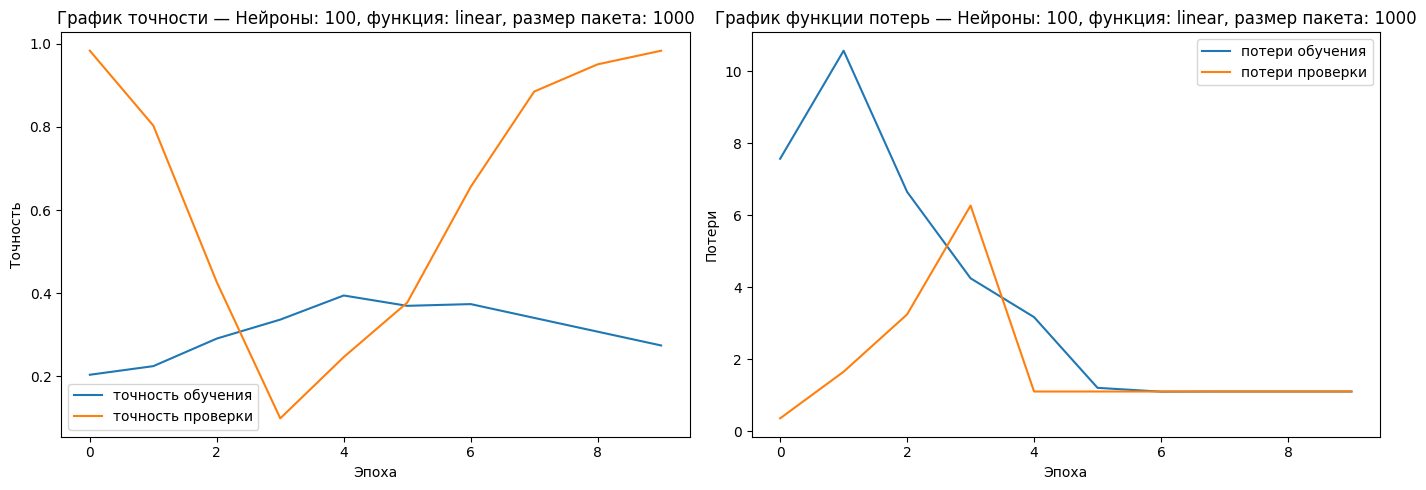

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3874 - loss: 1.0986     


In [17]:
model = Sequential() # Создание модели

# Добавление слоев с 100 нейронами, функция активации linear
model.add(Flatten(input_shape=(20, 20, 1)))
model.add(Dense(100, input_dim = 400, activation='linear'))
model.add(Dense(3))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Задание batch_size=1000
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=1000,
    validation_split=0.2,
    verbose=1
)

plot_training_graphs(history, "Нейроны: 100, функция: linear, размер пакета: 1000")

# Измерение точности
loss, accuracy = model.evaluate(x_train, y_train)

# Список комбинаций параметров
results.append([100, "linear", 1000, accuracy])

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.3859 - loss: 8.9418 - val_accuracy: 0.0000e+00 - val_loss: 16.1181
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.4149 - loss: 9.4531 - val_accuracy: 0.0000e+00 - val_loss: 16.1181
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.4149 - loss: 9.4531 - val_accuracy: 0.0000e+00 - val_loss: 16.1181
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.4149 - loss: 9.4531 - val_accuracy: 0.0000e+00 - val_loss: 16.1181
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.4149 - loss: 9.4531 - val_accuracy: 0.0000e+00 - val_loss: 16.1181
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.4149 - loss: 9.4531 - val_accuracy: 0.0000e+00 - val_loss: 16.1181
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.4149 - loss: 9.4531 - val_accuracy: 0.0000e+00 - val_loss: 16.1181
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.4149 - loss

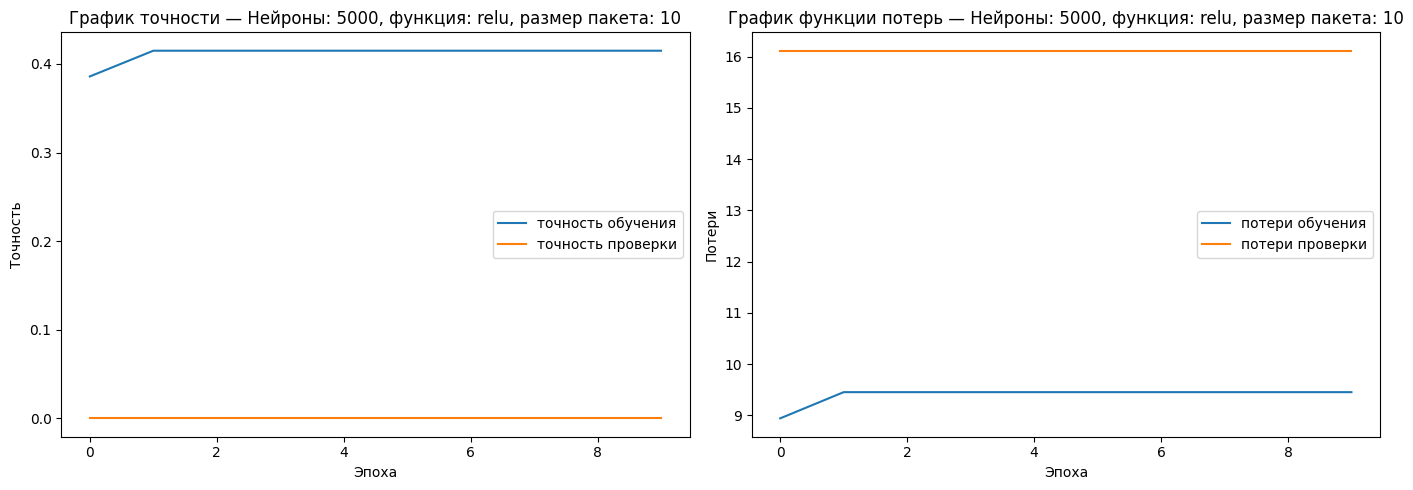

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3311 - loss: 10.7993


In [18]:
model = Sequential() # Создание модели

# Добавление слоев с 5000 нейронами, функция активации relu
model.add(Flatten(input_shape=(20, 20, 1)))
model.add(Dense(5000, input_dim = 400, activation='relu'))
model.add(Dense(3))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Задание batch_size=10
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=10,
    validation_split=0.2,
    verbose=1
)

plot_training_graphs(history, "Нейроны: 5000, функция: relu, размер пакета: 10")

# Измерение точности
loss, accuracy = model.evaluate(x_train, y_train)

# Список комбинаций параметров
results.append([5000, "relu", 10, accuracy])

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.3942 - loss: 7.6635 - val_accuracy: 0.0000e+00 - val_loss: 16.1181
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.4149 - loss: 9.4301 - val_accuracy: 0.0000e+00 - val_loss: 16.1181
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.4149 - loss: 9.4301 - val_accuracy: 0.0000e+00 - val_loss: 16.1181
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.4149 - loss: 9.4301 - val_accuracy: 0.0000e+00 - val_loss: 16.1181
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.4149 - loss: 9.4301 - val_accuracy: 0.0000e+00 - val_loss: 16.1181
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.4149 - loss: 9.4301 - val_accuracy: 0.0000e+00 - val_loss: 16.1181
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.4149 - loss: 9.4301 - val_accuracy: 0.0000e+00 - val_loss: 16.1181
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.4149 - loss: 9.4301 - val_

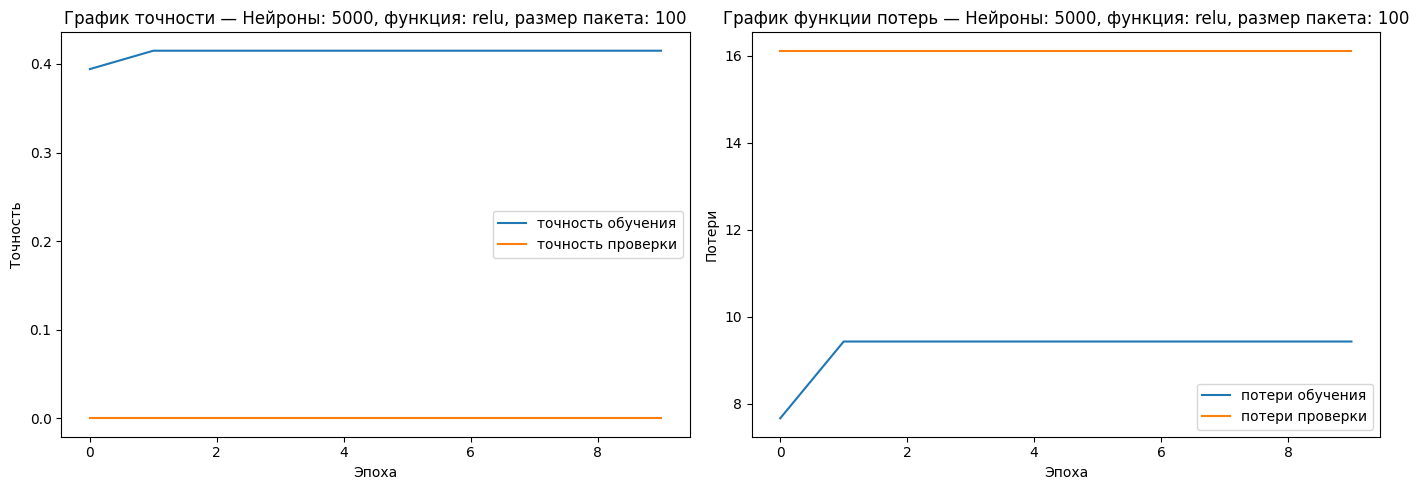

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3311 - loss: 10.7810


In [19]:
model = Sequential() # Создание модели

# Добавление слоев с 5000 нейронами, функция активации relu
model.add(Flatten(input_shape=(20, 20, 1)))
model.add(Dense(5000, input_dim = 400, activation='relu'))
model.add(Dense(3))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Задание batch_size=100
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=100,
    validation_split=0.2,
    verbose=1
)

plot_training_graphs(history, "Нейроны: 5000, функция: relu, размер пакета: 100")

# Измерение точности
loss, accuracy = model.evaluate(x_train, y_train)

# Список комбинаций параметров
results.append([5000, "relu", 100, accuracy])

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.3195 - loss: 3.0000 - val_accuracy: 0.0000e+00 - val_loss: 1.0986
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.4149 - loss: 1.0986 - val_accuracy: 0.0000e+00 - val_loss: 1.0986
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.4149 - loss: 1.0895 - val_accuracy: 0.0000e+00 - val_loss: 1.0986
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.4149 - loss: 1.0804 - val_accuracy: 0.0000e+00 - val_loss: 1.0986
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.4149 - loss: 1.0758 - val_accuracy: 0.0000e+00 - val_loss: 1.0986
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.4149 - loss: 1.0621 - val_accuracy: 0.0000e+00 - val_loss: 1.0986
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.4149 - loss: 1.0439 - val_accuracy: 0.0000e+00 - val_loss: 1.3069
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - accuracy: 0.4149 - loss: 1.0394 - val_acc

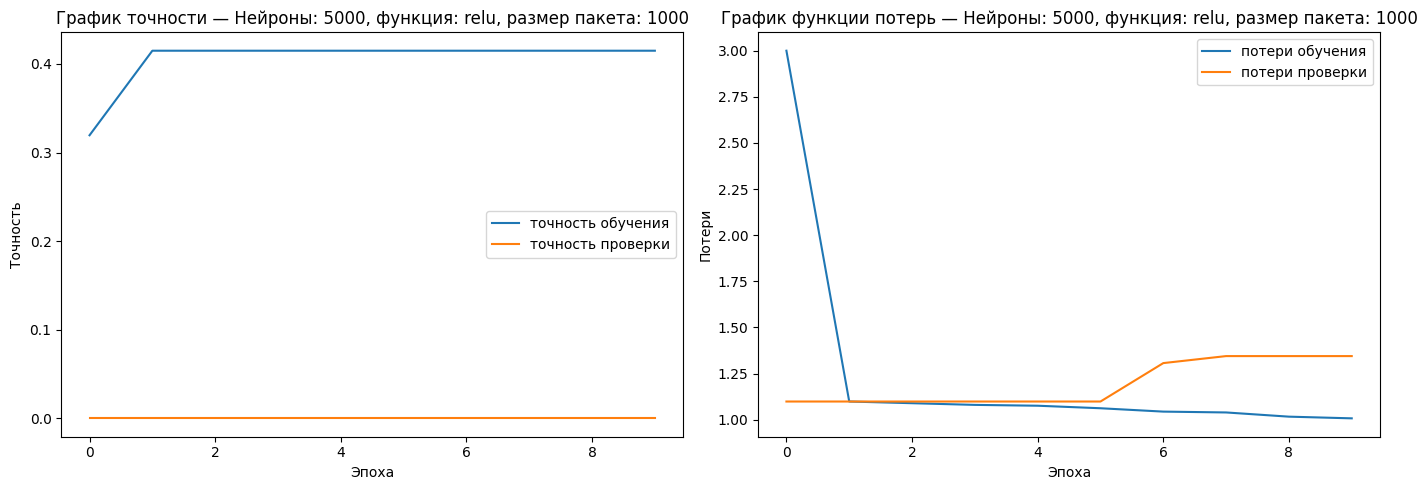

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3311 - loss: 1.0574


In [20]:
model = Sequential() # Создание модели

# Добавление слоев с 5000 нейронами, функция активации relu
model.add(Flatten(input_shape=(20, 20, 1)))
model.add(Dense(5000, input_dim = 400, activation='relu'))
model.add(Dense(3))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Задание batch_size=1000
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=1000,
    validation_split=0.2,
    verbose=1
)

plot_training_graphs(history, "Нейроны: 5000, функция: relu, размер пакета: 1000")

# Измерение точности
loss, accuracy = model.evaluate(x_train, y_train)

# Список комбинаций параметров
results.append([5000, "relu", 1000, accuracy])

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.3942 - loss: 3.5471 - val_accuracy: 0.0000e+00 - val_loss: 16.1181
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.4149 - loss: 9.4301 - val_accuracy: 0.0000e+00 - val_loss: 16.1181
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.4149 - loss: 9.4301 - val_accuracy: 0.0000e+00 - val_loss: 16.1181
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.4149 - loss: 9.4301 - val_accuracy: 0.0000e+00 - val_loss: 16.1181
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.4149 - loss: 9.4301 - val_accuracy: 0.0000e+00 - val_loss: 16.1181
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.4149 - loss: 9.4301 - val_accuracy: 0.0000e+00 - val_loss: 16.1181
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.4149 - loss: 9.4301 - val_accuracy: 0.0000e+00 - val_loss: 16.1181
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.4149 - loss

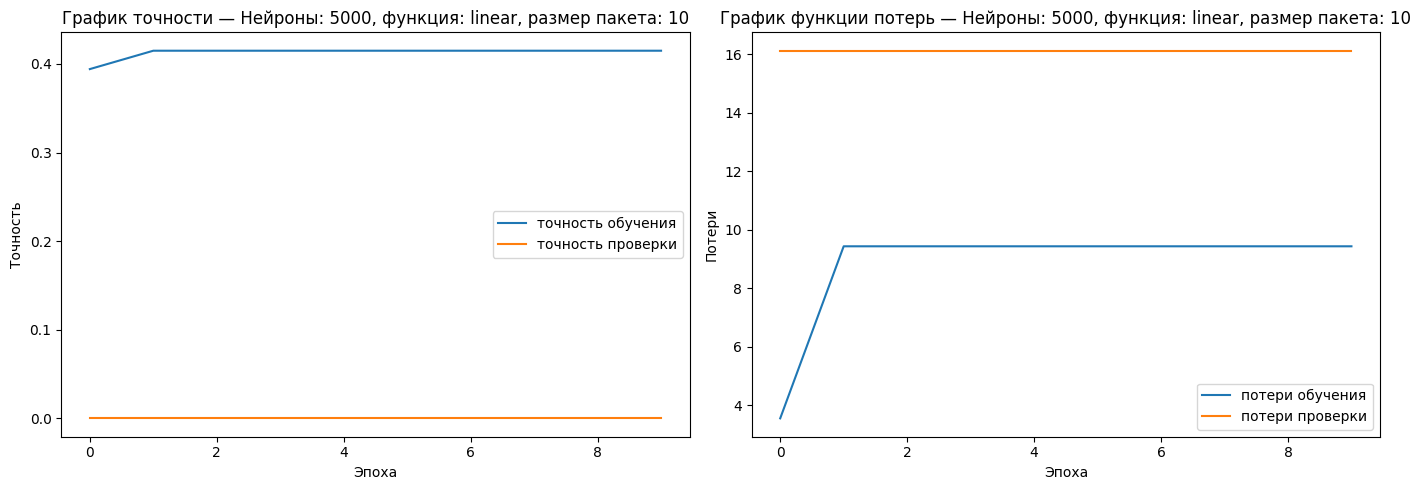

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3311 - loss: 10.7810


In [21]:
model = Sequential() # Создание модели

# Добавление слоев с 5000 нейронами, функция активации linear
model.add(Flatten(input_shape=(20, 20, 1)))
model.add(Dense(5000, input_dim = 400, activation='linear'))
model.add(Dense(3))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Задание batch_size=10
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=10,
    validation_split=0.2,
    verbose=1
)

plot_training_graphs(history, "Нейроны: 5000, функция: linear, размер пакета: 10")

# Измерение точности
loss, accuracy = model.evaluate(x_train, y_train)

# Список комбинаций параметров
results.append([5000, "linear", 10, accuracy])

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 250ms/step - accuracy: 0.5145 - loss: 4.0000 - val_accuracy: 0.0000e+00 - val_loss: 12.1634
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - accuracy: 0.4149 - loss: 3.1143 - val_accuracy: 0.0000e+00 - val_loss: 16.8112
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.4813 - loss: 3.4352 - val_accuracy: 0.0000e+00 - val_loss: 16.8112
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.4274 - loss: 3.4352 - val_accuracy: 0.0000e+00 - val_loss: 16.8112
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.4191 - loss: 3.4352 - val_accuracy: 0.0000e+00 - val_loss: 16.8112
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.4191 - loss: 3.4352 - val_accuracy: 0.0000e+00 - val_loss: 16.8112
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.4191 - loss: 3.4352 - val_accuracy: 0.0000e+00 - val_loss: 16.8112
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.4191 - loss: 3.4352 - 

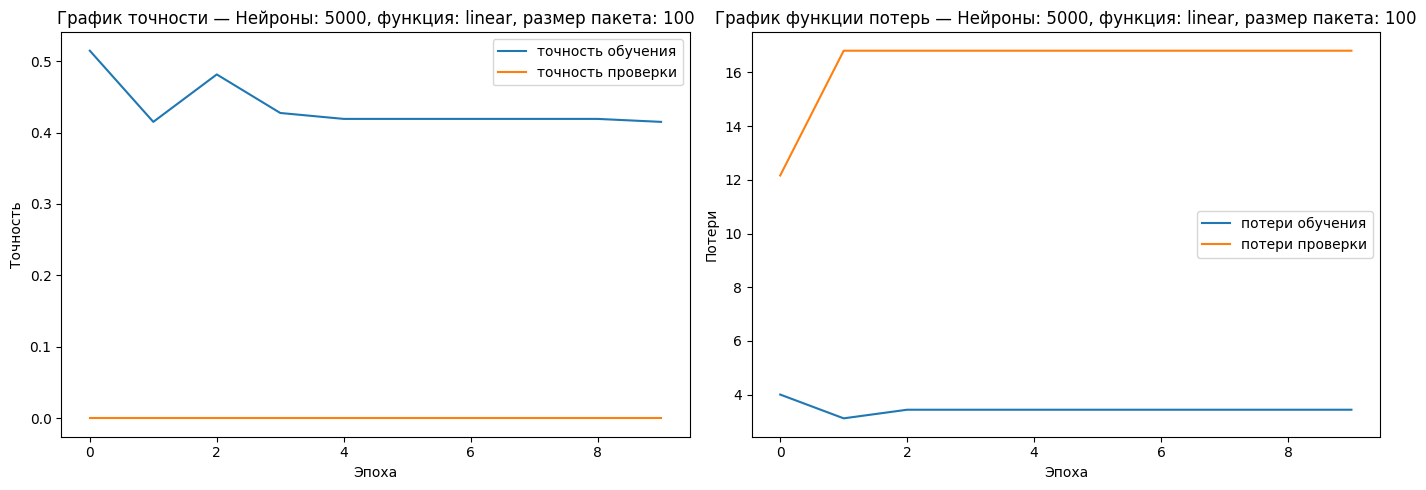

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3311 - loss: 6.1370


In [22]:
model = Sequential() # Создание модели

# Добавление слоев с 5000 нейронами, функция активации linear
model.add(Flatten(input_shape=(20, 20, 1)))
model.add(Dense(5000, input_dim = 400, activation='linear'))
model.add(Dense(3))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Задание batch_size=100
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=100,
    validation_split=0.2,
    verbose=1
)

plot_training_graphs(history, "Нейроны: 5000, функция: linear, размер пакета: 100")

# Измерение точности
loss, accuracy = model.evaluate(x_train, y_train)

# Список комбинаций параметров
results.append([5000, "linear", 100, accuracy])

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.2863 - loss: 3.3728 - val_accuracy: 1.0000 - val_loss: 2.3842e-07
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.1701 - loss: 13.3137 - val_accuracy: 1.0000 - val_loss: 2.3842e-07
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.1701 - loss: 13.3760 - val_accuracy: 1.0000 - val_loss: 2.3842e-07
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.1701 - loss: 13.3760 - val_accuracy: 1.0000 - val_loss: 2.3842e-07
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.1701 - loss: 13.3760 - val_accuracy: 1.0000 - val_loss: 2.3842e-07
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.1701 - loss: 13.3760 - val_accuracy: 1.0000 - val_loss: 2.3842e-07
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - accuracy: 0.1701 - loss: 13.3760 - val_accuracy: 1.0000 - val_loss: 2.3842e-07
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.1701 - loss: 13.3760 - 

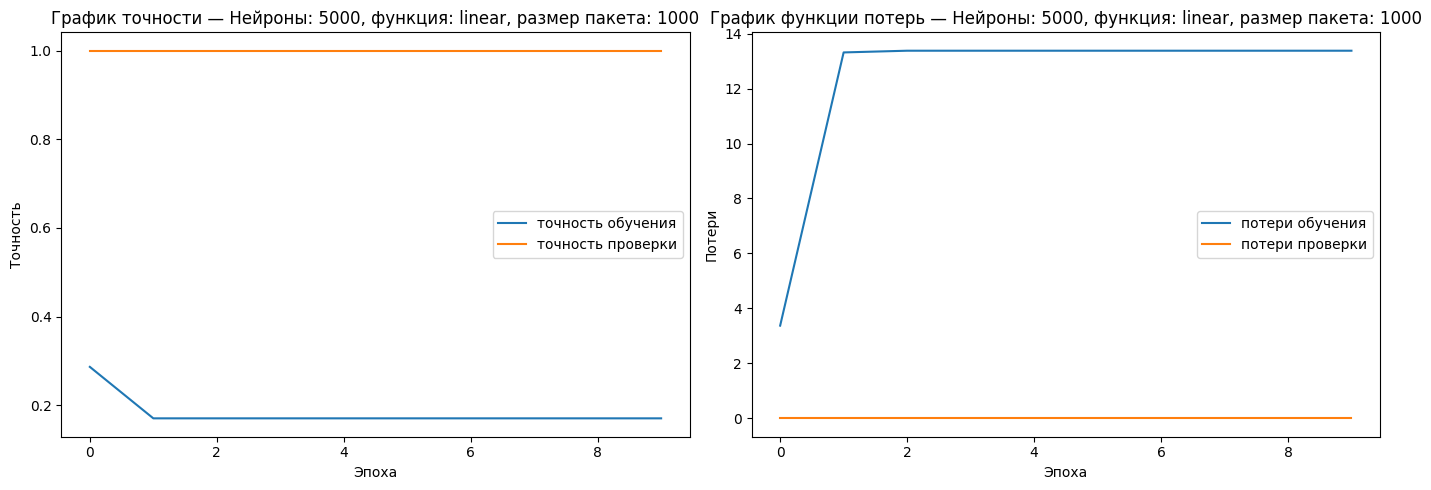

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3377 - loss: 10.6742


In [23]:
model = Sequential() # Создание модели

# Добавление слоев с 5000 нейронами, функция активации linear
model.add(Flatten(input_shape=(20, 20, 1)))
model.add(Dense(5000, input_dim = 400, activation='linear'))
model.add(Dense(3))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Задание batch_size=1000
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=1000,
    validation_split=0.2,
    verbose=1
)

plot_training_graphs(history, "Нейроны: 5000, функция: linear, размер пакета: 1000")

# Измерение точности
loss, accuracy = model.evaluate(x_train, y_train)

# Список комбинаций параметров
results.append([5000, "linear", 1000, accuracy])

In [24]:
# Отдельная ячейка - Простое сохранение весов
from google.colab import files

# Сохраняем веса текущей модели (последней обученной)
model.save_weights('lite.weights.h5')
print("✓ Веса сохранены в lite.weights.h5")

✓ Веса сохранены в lite.weights.h5


In [25]:
# Вывод итоговой таблицы
import pandas as pd

df = pd.DataFrame(results, columns=["Нейроны", "Активация", "Batch size", "Точность"])
print(df)

    Нейроны Активация  Batch size  Точность
0        10      relu          10  0.440397
1        10      relu         100  0.331126
2        10      relu        1000  0.443709
3        10    linear          10  0.331126
4        10    linear         100  0.331126
5        10    linear        1000  0.380795
6       100      relu          10  0.327815
7       100      relu         100  0.331126
8       100      relu        1000  0.344371
9       100    linear          10  0.337748
10      100    linear         100  0.268212
11      100    linear        1000  0.387417
12     5000      relu          10  0.331126
13     5000      relu         100  0.331126
14     5000      relu        1000  0.331126
15     5000    linear          10  0.331126
16     5000    linear         100  0.331126
17     5000    linear        1000  0.337748
